In [49]:
### Import all necessary packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

### 1. EDA

In [6]:
### Load dataset
df=pd.read_csv('diabetes.csv')

In [7]:
### dataset size
df.shape

(768, 9)

In [8]:
### data information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [9]:
### First 5 Rows
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [10]:
### Check Duplicates
df.duplicated().sum()

np.int64(0)

    No Duplicates

In [11]:
### Check missing values
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

    No missing values

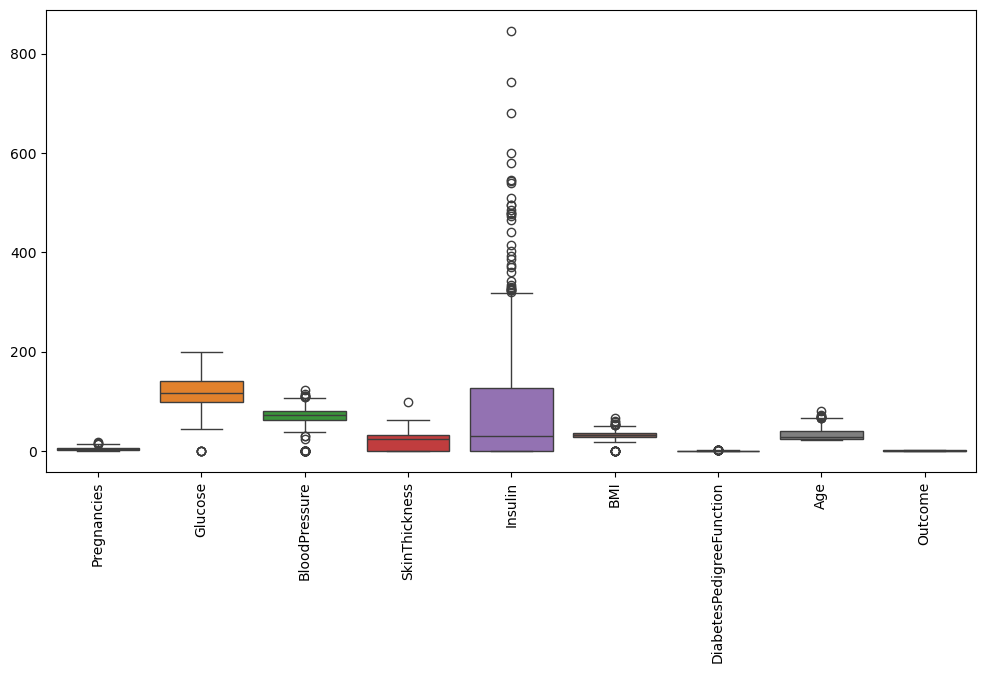

In [12]:
### Outlier check
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

In [13]:
#### outlier capping
def outlier_capping(df,column):
    Q1= df[column].quantile(0.25)
    Q3= df[column].quantile(0.75)
    IQR= Q3-Q1
    lower_extreme= Q1-1.5*IQR
    upper_extreme= Q3+1.5*IQR
    df[column]= df[column].apply(lambda x: lower_extreme if x<lower_extreme else upper_extreme if x>upper_extreme else x)
for col in df.select_dtypes(include=['int','float']).columns:
    outlier_capping(df,col)

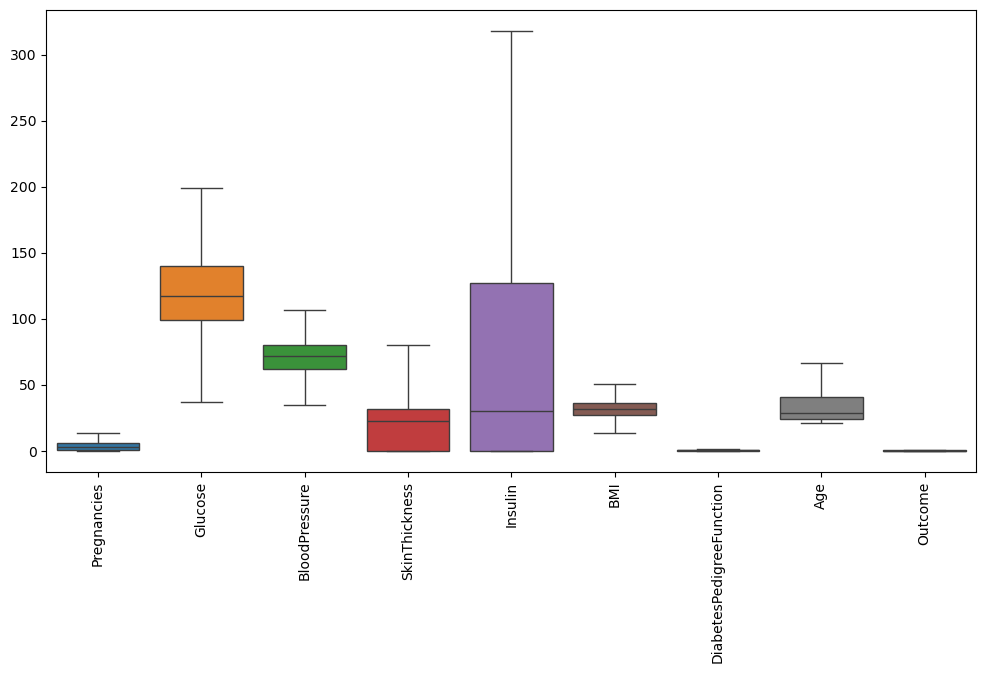

In [14]:
### Outlier check after capping
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

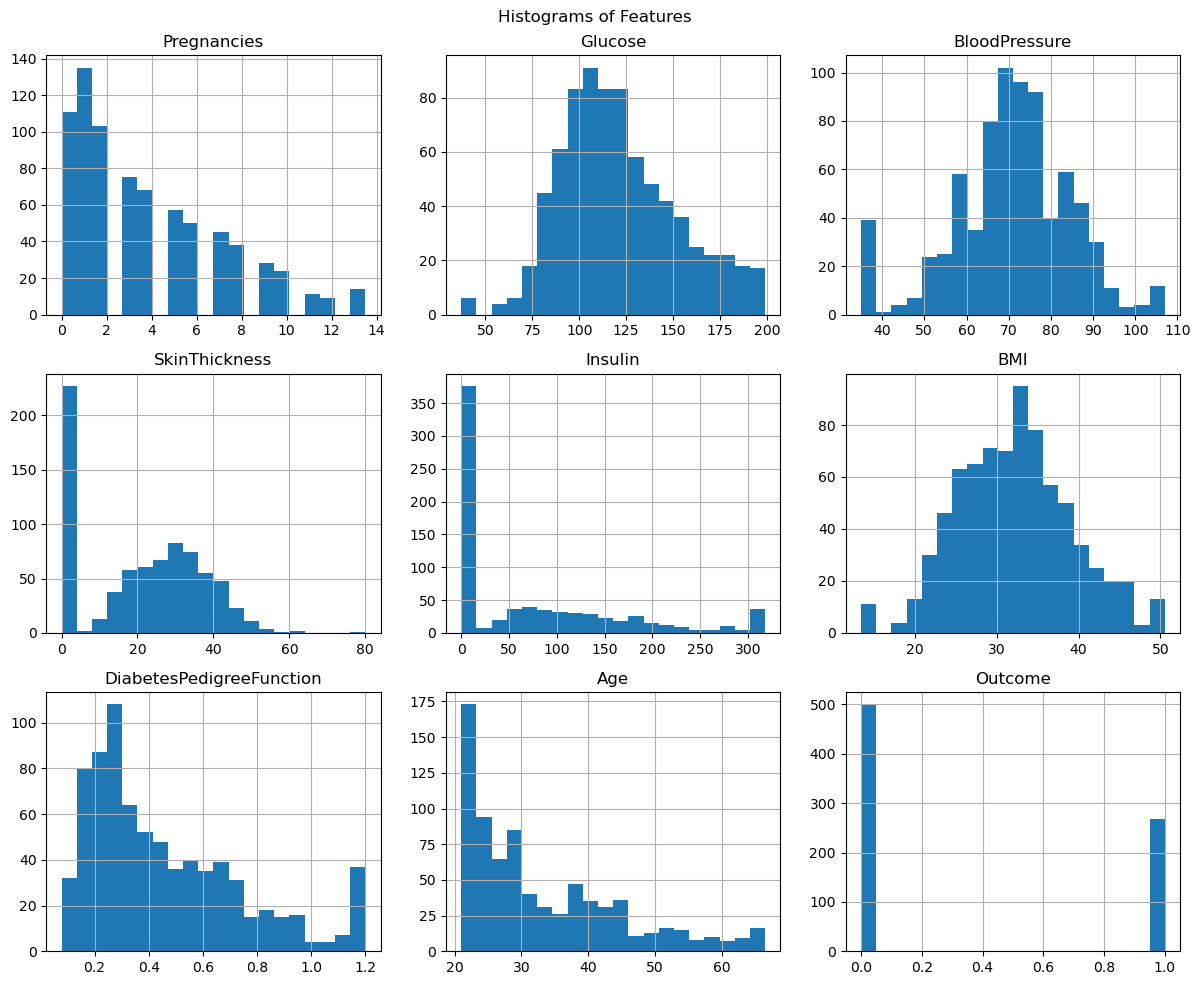

In [15]:
### Histogram for understanding the features
df.hist(figsize=(12,10), bins=20)
plt.suptitle("Histograms of Features")
plt.tight_layout()
plt.show()

* Most features show an uneven distribution.
* Glucose, BloodPressure, and BMI are close to a normal distribution.
* Pregnancies, Insulin, DiabetesPedigreeFunction, and Age are positively skewed.
* SkinThickness and Insulin contain many 0 values.
* The Outcome variable has two classes, with more non-diabetic (0) cases than diabetic (1) cases.

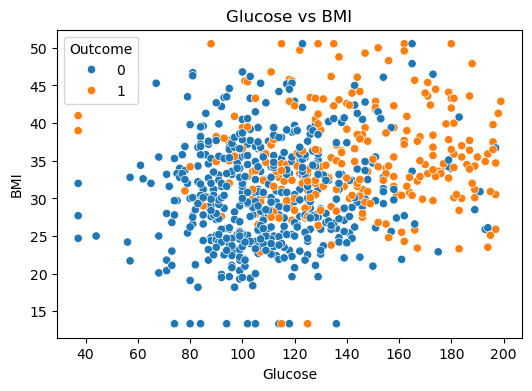

In [17]:
### Scatter plot
plt.figure(figsize=(6,4))
sns.scatterplot(x='Glucose', y='BMI', hue='Outcome', data=df)
plt.title("Glucose vs BMI")
plt.show()

* The scatter plot shows the relationship between Glucose and BMI.
* Patients with higher glucose levels are more likely to have Outcome = 1 (diabetes).
* The two classes overlap, so they cannot be clearly separated using only these two features.

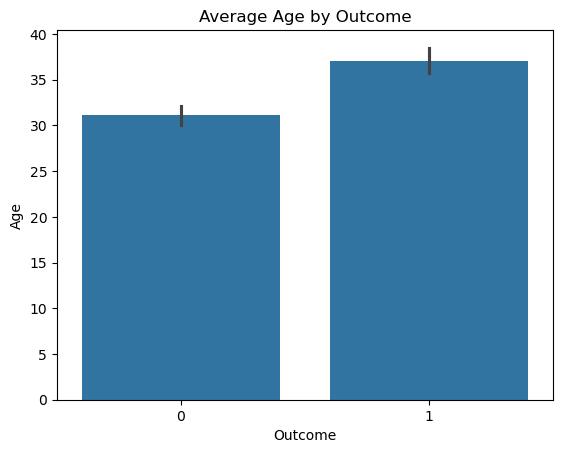

In [18]:
### Bar Chart
sns.barplot(x='Outcome', y='Age', data=df)
plt.title("Average Age by Outcome")
plt.show()

### 2. Data Preprocessing:

In [20]:
### Impute missing values
df.isnull().sum().sum()

np.int64(0)

No missing values

In [19]:
### Encoding
df.dtypes

Pregnancies                 float64
Glucose                     float64
BloodPressure               float64
SkinThickness               float64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                         float64
Outcome                       int64
dtype: object

* All features are numerical.
* No categorical columns are present.
* Therefore, one-hot encoding or label encoding is not required.

### 3. Building Predictive Models:

In [21]:
### Seperate features Aand target
target= df['Outcome']
features = df.drop('Outcome', axis=1)

In [23]:
### Train-test_Split
x_train,x_test,y_train,y_test=train_test_split(features,target,train_size=0.8,random_state=100,stratify=target)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(614, 8)
(154, 8)
(614,)
(154,)


* The dataset was divided into training and testing sets using an 80:20 ratio.
* The training feature dataset (x_train) contains 614 samples with 8 features, which are used to train the model.
* The testing feature dataset (x_test) contains 154 samples with 8 features, which are used to evaluate model performance.
* The training target (y_train) contains 614 output values, and the testing target (y_test) contains 154 output values.
* stratify=target ensured that the proportion of diabetic and non-diabetic cases remained similar in both training and testing datasets.

#### Model Building

In [25]:
### XGBoost (Extreme Gradient Boosting) 
xgb_model = XGBClassifier(n_estimators=100,learning_rate=0.1,max_depth=3,andom_state=100)
xgb_model.fit(x_train, y_train)
y_pred_xgb = xgb_model.predict(x_test)
accuracy_score(y_test, y_pred_xgb)

0.8051948051948052

In [27]:
print(classification_report(y_test,y_pred_xgb))

              precision    recall  f1-score   support

           0       0.84      0.86      0.85       100
           1       0.73      0.70      0.72        54

    accuracy                           0.81       154
   macro avg       0.79      0.78      0.78       154
weighted avg       0.80      0.81      0.80       154



In [33]:
### LightGBM (Light Gradient Boosting Machine)
lgbm_model = LGBMClassifier(n_estimators=100,learning_rate=0.1,max_depth=3,random_state=100, verbosity=-1)
lgbm_model.fit(x_train, y_train)
y_pred_lgbm = lgbm_model.predict(x_test)
accuracy_score(y_test, y_pred_lgbm)

0.7597402597402597

In [53]:
print(classification_report(y_test,y_pred_lgbm))

              precision    recall  f1-score   support

           0       0.81      0.83      0.82       100
           1       0.67      0.63      0.65        54

    accuracy                           0.76       154
   macro avg       0.74      0.73      0.73       154
weighted avg       0.76      0.76      0.76       154



#### XGBoost Hyperparameter Tuning using GridSearchCV

In [54]:
from sklearn.model_selection import GridSearchCV

xgb = XGBClassifier(random_state=100)

param_grid_xgb = {'n_estimators': [50, 100, 150],'max_depth': [2, 3, 5],'learning_rate': [0.01, 0.1, 0.2]}
grid_xgb = GridSearchCV(estimator=xgb,param_grid=param_grid_xgb,cv=5,scoring='accuracy')

grid_xgb.fit(x_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.1, ...], 'max_depth': [2, 3, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, defa

In [55]:
### Best Parameters
print(grid_xgb.best_params_)

{'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 50}


In [56]:
### Best cross validation score
print(grid_xgb.best_score_)

0.7573637211781954


In [57]:
###Tuned XGBoost
best_xgb = grid_xgb.best_estimator_

y_pred_tuned_xgb = best_xgb.predict(x_test)

print("Tuned XGBoost Accuracy:",
      accuracy_score(y_test, y_pred_tuned_xgb))

Tuned XGBoost Accuracy: 0.7727272727272727


### LightGBM Hyperparameter Tuning using GridSearchCV

In [58]:
lgbm = LGBMClassifier(random_state=100)

param_grid_lgbm = {'n_estimators': [50, 100, 150],'max_depth': [2, 3, 5],'learning_rate': [0.01, 0.1, 0.2]}
grid_lgbm = GridSearchCV(estimator=lgbm,param_grid=param_grid_lgbm,cv=5,scoring='accuracy')

grid_lgbm.fit(x_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LGBMClassifie...dom_state=100)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.1, ...], 'max_depth': [2, 3, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, defaul

In [59]:
### Best Parameters
print(grid_lgbm.best_params_)

{'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 50}


In [60]:
### ### Best cross validation score
print(grid_lgbm.best_score_)

0.7590030654404905


In [ ]:
### Tuned LightGBM

In [61]:
best_lgbm = grid_lgbm.best_estimator_

y_pred_tuned_lgbm = best_lgbm.predict(x_test)

print("Tuned LightGBM Accuracy:",
      accuracy_score(y_test, y_pred_tuned_lgbm))

Tuned LightGBM Accuracy: 0.7662337662337663


* Hyperparameter tuning was performed using GridSearchCV with 5-fold cross-validation.
* The tuned XGBoost model achieved 77.27% accuracy.
* The tuned LightGBM model achieved 76.62% accuracy.
* XGBoost performed better overall and was selected as the final model for this dataset.

### 4. Comparative Analysis:

In [50]:
### Comparison
results = pd.DataFrame({
    "Model": ["XGBoost", "LightGBM"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_xgb)*100,
        accuracy_score(y_test, y_pred_lgbm)*100
    ],
    "Precision": [
        precision_score(y_test, y_pred_xgb)*100,
        precision_score(y_test, y_pred_lgbm)*100
    ],
    "Recall": [
        recall_score(y_test, y_pred_xgb)*100,
        recall_score(y_test, y_pred_lgbm)*100
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_xgb)*100,
        f1_score(y_test, y_pred_lgbm)*100
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,XGBoost,80.519481,73.076923,70.370370,71.698113
1,LightGBM,75.974026,66.666667,62.962963,64.761905


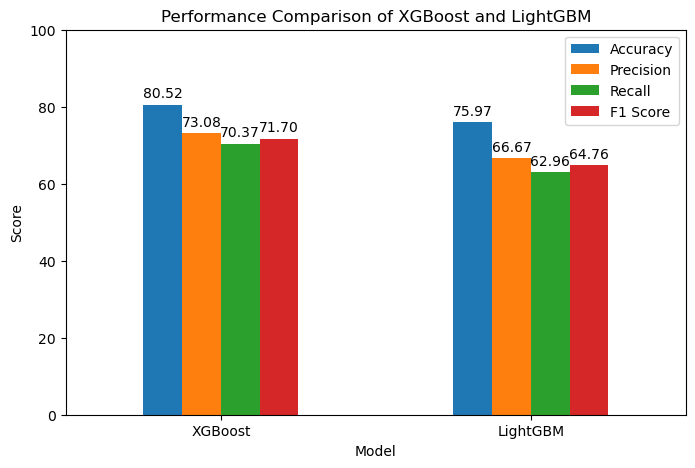

In [52]:
ax = results.set_index("Model").plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Performance Comparison of XGBoost and LightGBM")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0,100)
plt.xticks(rotation=0)

# Add values above bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)

plt.show()

* Both XGBoost and LightGBM models were evaluated using accuracy, precision, recall, and F1-score.
* XGBoost performed better than LightGBM on the diabetes dataset.
* XGBoost achieved an accuracy of 80.51%, while LightGBM achieved 75.97% accuracy.
* XGBoost also showed higher precision (73.07%), recall (70.37%), and F1-score (71.69%) compared to LightGBM.
* The higher recall value of XGBoost indicates that it was better at identifying diabetic cases correctly.
* LightGBM provided reasonable performance but showed lower prediction capability compared to XGBoost for this dataset.
* Based on these evaluation metrics, XGBoost is the better-performing model for diabetes prediction in this comparison.

**Strengths of XGBoost**

* Achieved the highest accuracy (80.52%).
* Better precision, recall, and F1-score than LightGBM.
* More effective in predicting diabetes cases.

**Weaknesses of XGBoost**

* Training time is generally higher than LightGBM.
* Hyperparameter tuning did not improve its performance on this dataset.

**Strengths of LightGBM**

* Faster training and efficient on large datasets.
* Achieved performance close to XGBoost.
* Slight improvement after hyperparameter tuning.

**Weaknesses of LightGBM**

* Lower accuracy, precision, recall, and F1-score than XGBoost on this dataset.
* Missed more diabetic cases compared to XGBoost.